In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

panel = pd.read_csv('/Users/aryan/Documents/geopolitical-student-mobility/data/processed/panel_dataset.csv')
panel.shape

(416, 25)

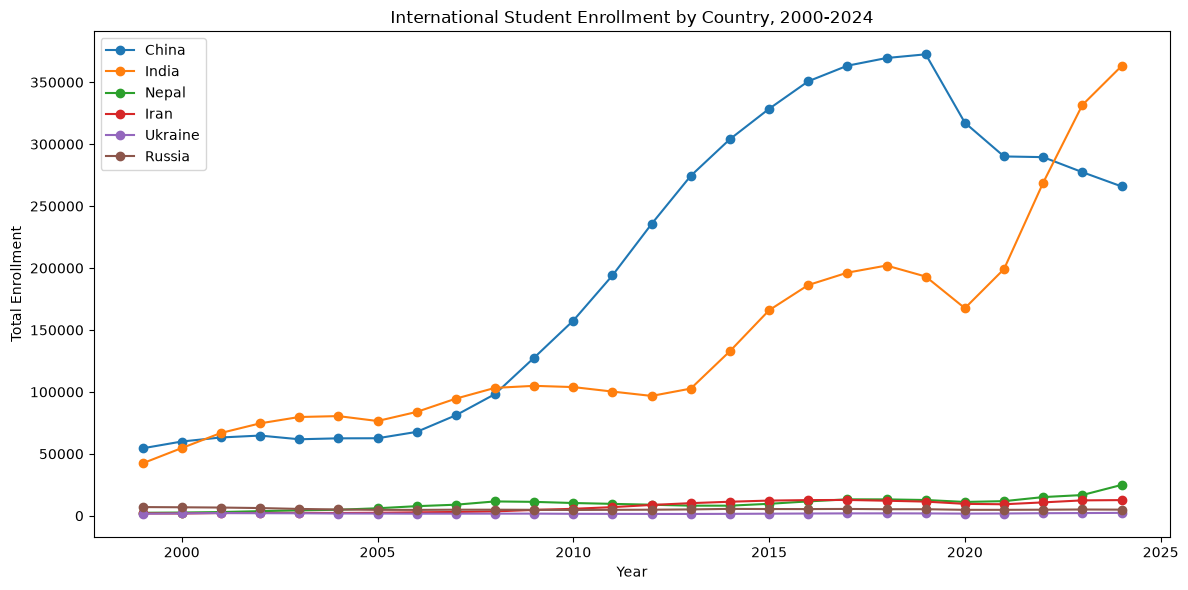

In [2]:
key_countries = ['China', 'India', 'Nepal', 'Iran', 'Ukraine', 'Russia']

fig, ax = plt.subplots(figsize=(12, 6))
for country in key_countries:
    subset = panel[panel.country == country].sort_values('panel_year')
    ax.plot(subset['panel_year'], subset['total_enrollment'], marker='o', label=country)

ax.set_xlabel('Year')
ax.set_ylabel('Total Enrollment')
ax.set_title('International Student Enrollment by Country, 2000-2024')
ax.legend()
plt.tight_layout()
plt.show()

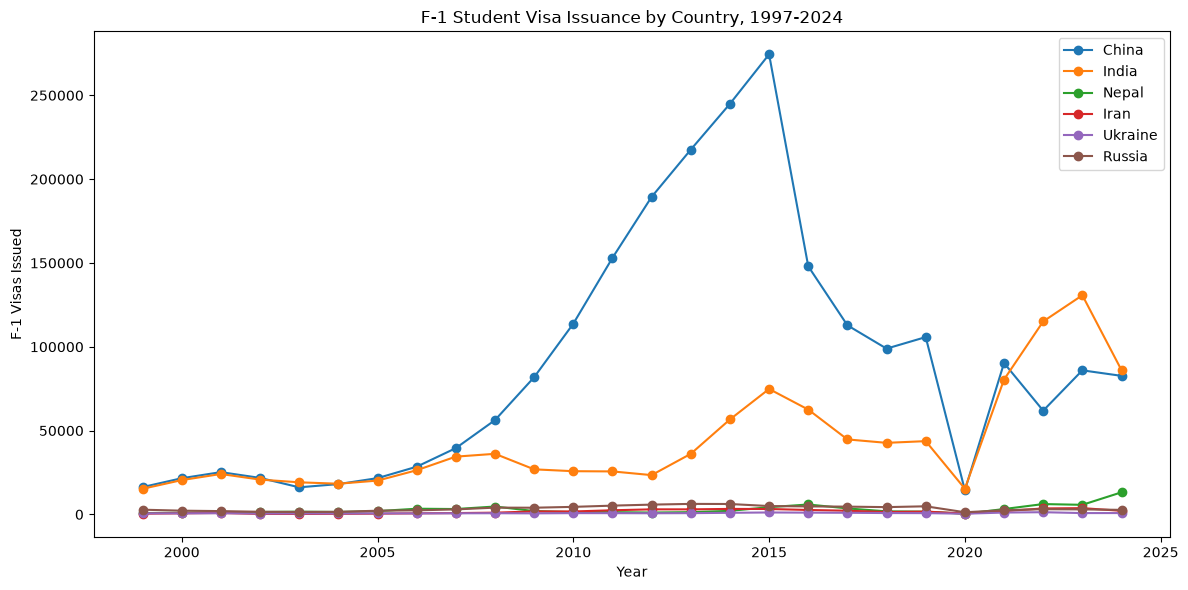

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
for country in key_countries:
    subset = panel[panel.country == country].sort_values('panel_year')
    ax.plot(subset['panel_year'], subset['f1_visas_issued'], marker='o', label=country)

ax.set_xlabel('Year')
ax.set_ylabel('F-1 Visas Issued')
ax.set_title('F-1 Student Visa Issuance by Country, 1997-2024')
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
all_countries = panel['country'].unique()
drop_check = []
for country in all_countries:
    sub = panel[panel.country == country].sort_values('panel_year')
    v2015 = sub[sub.panel_year == 2015]['f1_visas_issued'].values
    v2016 = sub[sub.panel_year == 2016]['f1_visas_issued'].values
    if len(v2015) and len(v2016) and v2015[0] and v2016[0]:
        pct_change = (v2016[0] - v2015[0]) / v2015[0] * 100
        drop_check.append({'country': country, 'f1_2015': v2015[0], 'f1_2016': v2016[0], 'pct_change': round(pct_change, 1)})

drop_df = pd.DataFrame(drop_check).sort_values('pct_change')
print(drop_df.to_string(index=False))

    country  f1_2015  f1_2016  pct_change
      China   274460   148016       -46.1
     Mexico    17636    11678       -33.8
     Brazil    14344    10978       -23.5
       Iran     3241     2650       -18.2
      India    74831    62537       -16.4
    Vietnam    17674    15680       -11.3
    Ukraine     1163     1057        -9.1
South Korea    27324    25355        -7.2
     Israel     1101     1041        -5.4
     Russia     4987     4776        -4.2
      Japan    17203    16668        -3.1
Afghanistan      243      237        -2.5
    Nigeria     6054     6758        11.6
       Iraq      347      393        13.3
     Canada      296      365        23.3
      Nepal     4309     5928        37.6


In [5]:
# Cell 5 - Russia and Ukraine around SH007 (2022 invasion)
for country in ['Russia', 'Ukraine']:
    sub = panel[(panel.country == country) & (panel.panel_year.between(2018, 2024))]
    print(f"\n{country}:")
    print(sub[['panel_year', 'total_enrollment', 'f1_visas_issued']].to_string(index=False))


Russia:
 panel_year  total_enrollment  f1_visas_issued
       2018              5292             4350
       2019              5293             4845
       2020              4805             1291
       2021              4802             2491
       2022              4913             3119
       2023              5071             2988
       2024              4948             2721

Ukraine:
 panel_year  total_enrollment  f1_visas_issued
       2018              1953              816
       2019              1899              764
       2020              1739              430
       2021              1835             1106
       2022              2072             1326
       2023              2183              796
       2024              2346              810


In [6]:
# Cell 6 - percent change 2021->2022 across all countries, sorted
pct_2022 = []
for country in panel['country'].unique():
    sub = panel[panel.country == country].sort_values('panel_year')
    e2021 = sub[sub.panel_year == 2021]['total_enrollment'].values
    e2022 = sub[sub.panel_year == 2022]['total_enrollment'].values
    if len(e2021) and len(e2022) and e2021[0] and e2022[0]:
        pct = (e2022[0] - e2021[0]) / e2021[0] * 100
        pct_2022.append({'country': country, 'enrollment_2021': e2021[0], 'enrollment_2022': e2022[0], 'pct_change': round(pct, 1)})

pct_2022_df = pd.DataFrame(pct_2022).sort_values('pct_change')
print(pct_2022_df.to_string(index=False))

    country  enrollment_2021  enrollment_2022  pct_change
       Iraq              597              544        -8.9
     Israel             2027             2019        -0.4
      China           290086           289526        -0.2
     Mexico            14500            14541         0.3
     Russia             4802             4913         2.3
     Canada            27013            27876         3.2
    Vietnam            20713            21900         5.7
South Korea            40755            43847         7.6
     Brazil            14897            16025         7.6
    Ukraine             1835             2072        12.9
       Iran             9295            10812        16.3
      Japan            13449            16054        19.4
    Nigeria            14438            17640        22.2
      Nepal            11799            15090        27.9
      India           199182           268923        35.0
Afghanistan              420              682        62.4
